# Lab 13: CityLearn Demand Forecasting Project

**Student Name:** DANIYAL BASHARAT  
**Registration Number:** 22JZELE0467  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Project Overview
This notebook develops a machine learning/deep learning forecasting pipeline for the CityLearn challenge dataset. The code loads CityLearn data, combines building, weather, pricing, and carbon intensity files, prepares district-level electricity demand, performs feature engineering and scaling, creates time-series sequences, trains an LSTM model, and evaluates forecasting performance.

## Project Objectives
- Load and inspect the CityLearn dataset and available schema information.
- Collect building-level electricity data and combine it into district-level demand.
- Merge demand data with weather, pricing, and carbon intensity information.
- Clean missing values and perform feature engineering for time-series forecasting.
- Normalize data and create supervised learning sequences using a lookback window.
- Build, train, and evaluate an LSTM model for district demand forecasting.


## Section 1: Working Directory and Library Imports
This section sets the CityLearn Assignment working directory and imports data handling, visualization, preprocessing, TensorFlow/Keras, and evaluation libraries.


In [7]:
import os
os.chdir(r'Z:\University\8th Semester\ML Lab\CityLearn Assignment')

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input
from tensorflow.keras.models import Sequential, Model
from citylearn.data import DataSet
import pandas as pd
import time, pickle
import numpy as np
import tensorflow.keras.backend as K
import tensorflow
import glob
import h5py
import matplotlib.pyplot as plt
from keras.callbacks import Callback
import json

In [14]:
#lookback = 24
model = None
start_epoch = 0
time_steps=24
target_column='district_net_electricity_consumption'

In [15]:
citylearn_dataset = DataSet()

print('All CityLearn datasets:', sorted(citylearn_dataset.get_dataset_names()))

All CityLearn datasets: ['baeda_3dem', 'ca_alameda_county_neighborhood', 'citylearn_challenge_2020_climate_zone_1', 'citylearn_challenge_2020_climate_zone_2', 'citylearn_challenge_2020_climate_zone_3', 'citylearn_challenge_2020_climate_zone_4', 'citylearn_challenge_2021', 'citylearn_challenge_2022_phase_1', 'citylearn_challenge_2022_phase_2', 'citylearn_challenge_2022_phase_3', 'citylearn_challenge_2022_phase_all', 'citylearn_challenge_2022_phase_all_plus_evs', 'citylearn_challenge_2023_phase_1', 'citylearn_challenge_2023_phase_2_local_evaluation', 'citylearn_challenge_2023_phase_2_online_evaluation_1', 'citylearn_challenge_2023_phase_2_online_evaluation_2', 'citylearn_challenge_2023_phase_2_online_evaluation_3', 'citylearn_challenge_2023_phase_3_1', 'citylearn_challenge_2023_phase_3_2', 'citylearn_challenge_2023_phase_3_3', 'citylearn_charging_constraints_demo', 'quebec_neighborhood_with_demand_response_set_points', 'quebec_neighborhood_without_demand_response_set_points', 'tx_travis_

## Section 2: CityLearn Dataset Loading and Schema Inspection
The following cells inspect available CityLearn datasets, select the required challenge dataset, and read schema/building information.


In [16]:
dataset_name = 'citylearn_challenge_2022_phase_all'

dataset_names = citylearn_dataset.get_dataset_names()

if dataset_name not in dataset_names:
    print('Dataset not found:', dataset_name)
    print('Available datasets:', sorted(dataset_names))
else:
    schema = citylearn_dataset.get_schema(dataset_name)
    root_directory = schema['root_directory']

    print(root_directory)
    print(schema.keys())

INFO:root:Go here C:\Users\engin\AppData\Local\intelligent-environments-lab\citylearn\Cache\v2.5.0\datasets\citylearn_challenge_2022_phase_all\schema.json 


C:\Users\engin\AppData\Local\intelligent-environments-lab\citylearn\Cache\v2.5.0\datasets\citylearn_challenge_2022_phase_all
dict_keys(['random_seed', 'root_directory', 'central_agent', 'simulation_start_time_step', 'simulation_end_time_step', 'episode_time_steps', 'rolling_episode_split', 'random_episode_split', 'seconds_per_time_step', 'observations', 'actions', 'agent', 'reward_function', 'buildings'])


In [17]:
building_names = list(schema['buildings'].keys())
building_names[:5], len(building_names)

(['Building_1', 'Building_2', 'Building_3', 'Building_4', 'Building_5'], 17)

In [18]:
building_data = []

for building_name in building_names:
    filename = schema['buildings'][building_name]['energy_simulation']
    filepath = os.path.join(root_directory, filename)
    
    data = pd.read_csv(filepath)
    data['building_name'] = building_name
    building_data.append(data)

building_df = pd.concat(building_data, axis=0, ignore_index=True)
building_df.head()

,month,hour,day_type,daylight_savings_status,indoor_dry_bulb_temperature,average_unmet_cooling_setpoint_difference,indoor_relative_humidity,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation,building_name
0,7,24,7,0,NaN,NaN,NaN,2.275800,0.0,0.0,0.0,0.0,Building_1
1,8,1,1,0,NaN,NaN,NaN,0.851167,0.0,0.0,0.0,0.0,Building_1
2,8,2,1,0,NaN,NaN,NaN,0.834600,0.0,0.0,0.0,0.0,Building_1
3,8,3,1,0,NaN,NaN,NaN,0.838167,0.0,0.0,0.0,0.0,Building_1
4,8,4,1,0,NaN,NaN,NaN,1.478433,0.0,0.0,0.0,0.0,Building_1


In [19]:
building_df.shape

(148920, 13)

In [20]:
building_df.columns

Index(['month', 'hour', 'day_type', 'daylight_savings_status',
       'indoor_dry_bulb_temperature',
       'average_unmet_cooling_setpoint_difference', 'indoor_relative_humidity',
       'non_shiftable_load', 'dhw_demand', 'cooling_demand', 'heating_demand',
       'solar_generation', 'building_name'],
      dtype='str')

## Section 3: Building, Weather, Pricing, and Carbon Data Collection
This section loads building energy simulation files and supporting weather, pricing, and carbon intensity files required for district-level forecasting.


In [22]:
weather_file = schema['buildings'][building_names[0]]['weather']
pricing_file = schema['buildings'][building_names[0]]['pricing']
carbon_file = schema['buildings'][building_names[0]]['carbon_intensity']

weather = pd.read_csv(os.path.join(root_directory, weather_file))
pricing = pd.read_csv(os.path.join(root_directory, pricing_file))
carbon_intensity = pd.read_csv(os.path.join(root_directory, carbon_file))

weather.head(), pricing.head(), carbon_intensity.head()

(   outdoor_dry_bulb_temperature  outdoor_relative_humidity  \
 0                          20.0                       84.0   
 1                          20.1                       79.0   
 2                          19.7                       78.0   
 3                          19.3                       78.0   
 4                          18.9                       78.0   
 
    diffuse_solar_irradiance  direct_solar_irradiance  \
 0                       0.0                      0.0   
 1                       0.0                      0.0   
 2                       0.0                      0.0   
 3                       0.0                      0.0   
 4                       0.0                      0.0   
 
    outdoor_dry_bulb_temperature_predicted_1  \
 0                                      18.3   
 1                                      19.4   
 2                                      21.1   
 3                                      22.2   
 4                                  

In [23]:
building_df.isnull().sum()

month                                             0
hour                                              0
day_type                                          0
daylight_savings_status                           0
indoor_dry_bulb_temperature                  148920
average_unmet_cooling_setpoint_difference    148920
indoor_relative_humidity                     148920
non_shiftable_load                                0
dhw_demand                                        0
cooling_demand                                    0
heating_demand                                    0
solar_generation                                  0
building_name                                     0
dtype: int64

In [24]:
building_df = building_df.dropna(axis=1, how='all')
weather = weather.dropna(axis=1, how='all')
pricing = pricing.dropna(axis=1, how='all')
carbon_intensity = carbon_intensity.dropna(axis=1, how='all')

building_df.shape, weather.shape, pricing.shape, carbon_intensity.shape

((148920, 10), (8760, 16), (8760, 4), (8760, 1))

In [25]:
building_df.describe()

,month,hour,day_type,daylight_savings_status,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation
count,148920.000000,148920.00000,148920.000000,148920.0,148920.000000,148920.0,148920.0,148920.0,148920.000000
mean,6.526027,12.50000,3.992466,0.0,1.139162,0.0,0.0,0.0,155.877055
std,3.447863,6.92221,2.003414,0.0,1.108441,0.0,0.0,0.0,240.830052
min,1.000000,1.00000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
25%,4.000000,6.75000,2.000000,0.0,0.359113,0.0,0.0,0.0,0.000000
50%,7.000000,12.50000,4.000000,0.0,0.789617,0.0,0.0,0.0,0.000000
75%,10.000000,18.25000,6.000000,0.0,1.575487,0.0,0.0,0.0,265.795830
max,12.000000,24.00000,7.000000,0.0,8.846017,0.0,0.0,0.0,976.250000


In [26]:
possible_demand_columns = [
    'net_electricity_consumption',
    'Equipment Electric Power [kWh]',
    'equipment_electric_power',
    'non_shiftable_load',
    'Non Shiftable Load [kWh]'
]

demand_column = None

for col in possible_demand_columns:
    if col in building_df.columns:
        demand_column = col
        break

print('Selected demand column:', demand_column)

Selected demand column: non_shiftable_load


## Section 4: Data Cleaning and Exploratory Analysis
The following cells remove empty columns, check missing values, identify the demand column, summarize the dataset, and visualize average demand.


In [27]:
if demand_column is None:
    numeric_columns = building_df.select_dtypes(include=[np.number]).columns
    demand_column = numeric_columns[-1]
    print('Fallback demand column:', demand_column)

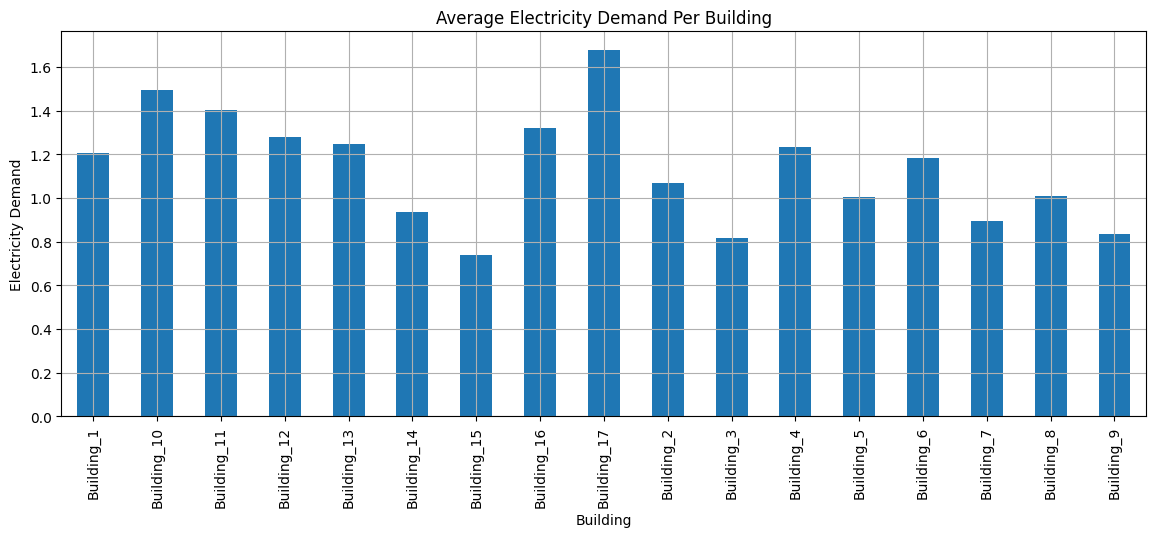

In [28]:
building_df.groupby('building_name')[demand_column].mean().plot(kind='bar', figsize=(14,5))
plt.title('Average Electricity Demand Per Building')
plt.xlabel('Building')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [29]:
building_df['time_step'] = building_df.groupby('building_name').cumcount()

district_load = building_df.groupby('time_step')[demand_column].sum().reset_index()
district_load = district_load.rename(columns={demand_column: target_column})

district_load.head()

,time_step,district_net_electricity_consumption
0,0,17.191467
1,1,12.272111
2,2,11.015850
3,3,10.258206
4,4,11.480795


In [30]:
weather['time_step'] = np.arange(len(weather))
pricing['time_step'] = np.arange(len(pricing))
carbon_intensity['time_step'] = np.arange(len(carbon_intensity))

data = district_load.merge(weather, on='time_step', how='left')
data = data.merge(pricing, on='time_step', how='left')
data = data.merge(carbon_intensity, on='time_step', how='left')

data.head()

,time_step,district_net_electricity_consumption,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,...,diffuse_solar_irradiance_predicted_2,diffuse_solar_irradiance_predicted_3,direct_solar_irradiance_predicted_1,direct_solar_irradiance_predicted_2,direct_solar_irradiance_predicted_3,electricity_pricing,electricity_pricing_predicted_1,electricity_pricing_predicted_2,electricity_pricing_predicted_3,carbon_intensity
0,0,17.191467,20.0,84.0,0.0,0.0,18.3,22.8,20.0,81.0,...,964.0,0.0,100.0,815.0,0.0,0.22,0.22,0.22,0.22,0.170724
1,1,12.272111,20.1,79.0,0.0,0.0,19.4,22.8,19.4,79.0,...,966.0,0.0,444.0,747.0,0.0,0.22,0.22,0.22,0.22,0.157319
2,2,11.015850,19.7,78.0,0.0,0.0,21.1,22.2,19.4,73.0,...,683.0,0.0,592.0,291.0,0.0,0.22,0.22,0.22,0.22,0.154503
3,3,10.258206,19.3,78.0,0.0,0.0,22.2,22.8,19.4,71.0,...,522.0,0.0,491.0,153.0,0.0,0.22,0.22,0.22,0.22,0.150945
4,4,11.480795,18.9,78.0,0.0,0.0,21.7,22.2,18.9,73.0,...,444.0,0.0,734.0,174.0,0.0,0.22,0.22,0.54,0.22,0.151820


In [32]:
data = data.ffill()
data = data.bfill()

data.isnull().sum().sum()

np.int64(0)

## Section 5: Feature Engineering and Dataset Merging
This section creates district-level load, merges external features, fills missing values, and creates time-based/cyclic features for forecasting.


In [33]:
data['hour'] = data['time_step'] % 24
data['day'] = data['time_step'] // 24
data['day_of_week'] = data['day'] % 7
data['month'] = (data['day'] // 30) + 1

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

data.head()

,time_step,district_net_electricity_consumption,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,...,electricity_pricing_predicted_3,carbon_intensity,hour,day,day_of_week,month,hour_sin,hour_cos,day_sin,day_cos
0,0,17.191467,20.0,84.0,0.0,0.0,18.3,22.8,20.0,81.0,...,0.22,0.170724,0,0,0,1,0.000000,1.000000,0.0,1.0
1,1,12.272111,20.1,79.0,0.0,0.0,19.4,22.8,19.4,79.0,...,0.22,0.157319,1,0,0,1,0.258819,0.965926,0.0,1.0
2,2,11.015850,19.7,78.0,0.0,0.0,21.1,22.2,19.4,73.0,...,0.22,0.154503,2,0,0,1,0.500000,0.866025,0.0,1.0
3,3,10.258206,19.3,78.0,0.0,0.0,22.2,22.8,19.4,71.0,...,0.22,0.150945,3,0,0,1,0.707107,0.707107,0.0,1.0
4,4,11.480795,18.9,78.0,0.0,0.0,21.7,22.2,18.9,73.0,...,0.22,0.151820,4,0,0,1,0.866025,0.500000,0.0,1.0


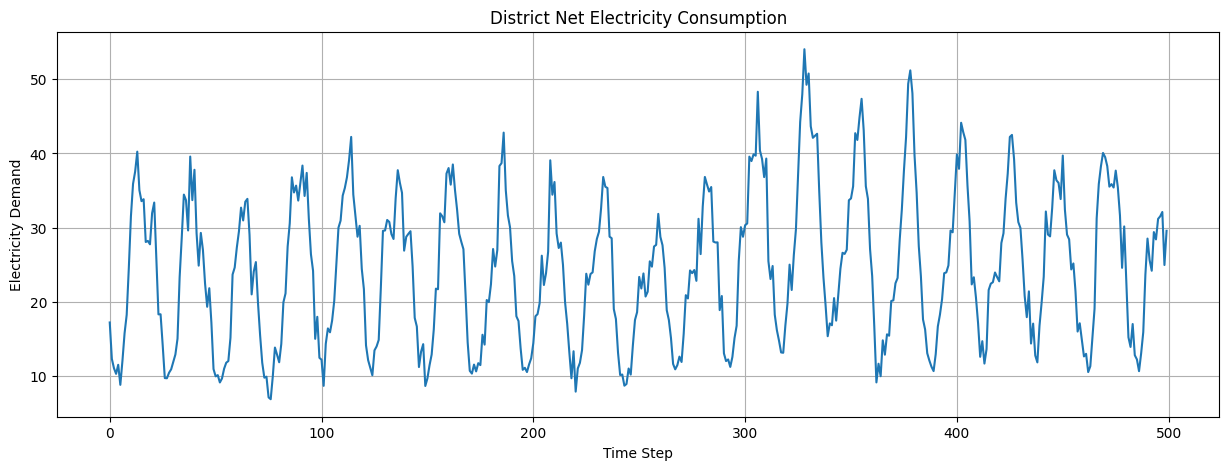

In [34]:
plt.figure(figsize=(15,5))
plt.plot(data[target_column][:500])
plt.title('District Net Electricity Consumption')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [35]:
numeric_data = data.select_dtypes(include=[np.number])

correlation = numeric_data.corr()[target_column].sort_values(ascending=False)
correlation.head(15)

district_net_electricity_consumption        1.000000
carbon_intensity                            0.475027
diffuse_solar_irradiance                    0.455345
diffuse_solar_irradiance_predicted_3        0.452520
direct_solar_irradiance                     0.373338
direct_solar_irradiance_predicted_3         0.370415
hour                                        0.364214
outdoor_dry_bulb_temperature                0.356484
outdoor_dry_bulb_temperature_predicted_3    0.345653
electricity_pricing_predicted_1             0.311393
outdoor_relative_humidity_predicted_2       0.291717
electricity_pricing_predicted_3             0.240827
electricity_pricing                         0.233181
outdoor_relative_humidity_predicted_1       0.204149
day_of_week                                 0.055355
Name: district_net_electricity_consumption, dtype: float64

In [36]:
feature_columns = list(numeric_data.columns)
feature_columns.remove(target_column)

selected_data = numeric_data[feature_columns + [target_column]]

selected_data.head()

,time_step,outdoor_dry_bulb_temperature,outdoor_relative_humidity,diffuse_solar_irradiance,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,outdoor_dry_bulb_temperature_predicted_3,outdoor_relative_humidity_predicted_1,outdoor_relative_humidity_predicted_2,...,carbon_intensity,hour,day,day_of_week,month,hour_sin,hour_cos,day_sin,day_cos,district_net_electricity_consumption
0,0,20.0,84.0,0.0,0.0,18.3,22.8,20.0,81.0,68.0,...,0.170724,0,0,0,1,0.000000,1.000000,0.0,1.0,17.191467
1,1,20.1,79.0,0.0,0.0,19.4,22.8,19.4,79.0,71.0,...,0.157319,1,0,0,1,0.258819,0.965926,0.0,1.0,12.272111
2,2,19.7,78.0,0.0,0.0,21.1,22.2,19.4,73.0,73.0,...,0.154503,2,0,0,1,0.500000,0.866025,0.0,1.0,11.015850
3,3,19.3,78.0,0.0,0.0,22.2,22.8,19.4,71.0,71.0,...,0.150945,3,0,0,1,0.707107,0.707107,0.0,1.0,10.258206
4,4,18.9,78.0,0.0,0.0,21.7,22.2,18.9,73.0,71.0,...,0.151820,4,0,0,1,0.866025,0.500000,0.0,1.0,11.480795


## Section 6: Scaling and Sequence Preparation
The following cells select numeric features, apply MinMax scaling, and convert the time-series data into supervised learning sequences.


In [37]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(selected_data)

scaled_data.shape

(8760, 31)

In [38]:
def create_sequences(data, time_steps=24):
    X = []
    y = []
    
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, :-1])
        y.append(data[i, -1])
        
    return np.array(X), np.array(y)

In [39]:
X, y = create_sequences(scaled_data, time_steps=time_steps)

X.shape, y.shape

((8736, 24, 30), (8736,))

In [40]:
train_size = int(len(X) * 0.70)
validation_size = int(len(X) * 0.15)

train_X = X[:train_size]
train_y = y[:train_size]

validation_X = X[train_size:train_size + validation_size]
validation_y = y[train_size:train_size + validation_size]

test_X = X[train_size + validation_size:]
test_y = y[train_size + validation_size:]

train_X.shape, validation_X.shape, test_X.shape

((6115, 24, 30), (1310, 24, 30), (1311, 24, 30))

In [41]:
num_features = train_X.shape[2]

num_features

30

## Section 7: Train, Validation, and Test Split
This section splits the generated sequences into train, validation, and test sets while preserving the chronological order of the time-series data.


In [42]:
def create_lstm():
    input_data = Input(shape=(time_steps, num_features))
    lstm_layer1 = LSTM(32, return_sequences=True)(input_data)
    dropout1 = Dropout(0.2)(lstm_layer1)
    lstm_layer2 = LSTM(16)(dropout1)
    output_data = Dense(1)(lstm_layer2)
    model = Model(input_data, output_data)
    return model

In [43]:
model1 = create_lstm()
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 32)         │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,217 (43.82 KB)

 Trainable params: 11,217 (43.82 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
tensorflow.keras.utils.plot_model(model1)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [45]:
checkpoints = r'Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
OUTPUT_PATH = r'Z:\University\8th Semester\ML Lab\CityLearn Assignment'
FIG_PATH = os.path.sep.join([OUTPUT_PATH,"\history.png"])
JSON_PATH = os.path.sep.join([OUTPUT_PATH,"\history.json"])

In [46]:
class TrainingMonitor(Callback):
    def __init__(self, figPath, jsonPath=None, startAt=0):
        super(TrainingMonitor, self).__init__()
        self.figPath = figPath
        self.jsonPath = jsonPath
        self.startAt = startAt
        
    def on_train_begin(self, logs={}):
        self.H = {}
        
        if self.jsonPath is not None:
            if os.path.exists(self.jsonPath):
                self.H = json.loads(open(self.jsonPath).read())
                
                if self.startAt > 0:
                    for k in self.H.keys():
                        self.H[k] = self.H[k][:self.startAt]
                        
    def on_epoch_end(self, epoch, logs={}):
        for (k, v) in logs.items():
            l = self.H.get(k, [])
            l.append(float(v))
            self.H[k] = l
            
        if self.jsonPath is not None:
            f = open(self.jsonPath, "w")
            f.write(json.dumps(self.H))
            f.close()
            
        if len(self.H["loss"]) > 1:
            N = np.arange(0, len(self.H["loss"]))
            plt.style.use("ggplot")
            plt.figure()
            plt.plot(N, self.H["loss"], label="train_loss")
            plt.plot(N, self.H["val_loss"], label="val_loss")
            plt.title("Training Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.savefig(self.figPath)
            plt.close()

## Section 8: LSTM Model Architecture and Training Setup
The following cells define the LSTM model, display the model summary, configure checkpoints, and prepare the training monitor callback.


In [47]:
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)

TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

callbacks = [EpochCheckpoint1,TrainingMonitor1]

In [48]:
if model is None:
    print("[INFO] compiling model...")
    model = create_lstm()
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))
    K.set_value(model.optimizer.learning_rate, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))

[INFO] compiling model...


In [49]:
epochs = 50
verbose = 1 #0
batch_size = 32

History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1162 - mae: 0.1162 - mape: 33001.6131
Epoch 1: val_loss improved from None to 0.10563, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0001-loss0.11.h5



Epoch 1: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0001-loss0.11.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.1017 - mae: 0.1017 - mape: 8873.4912 - val_loss: 0.1056 - val_mae: 0.1056 - val_mape: 84.2095
Epoch 2/50
189/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0862 - mae: 0.0862 - mape: 16980.6526
Epoch 2: val_loss improved from 0.10563 to 0.10007, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0002-loss0.10.h5



Epoch 2: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0002-loss0.10.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0856 - mae: 0.0856 - mape: 32159.6367 - val_loss: 0.1001 - val_mae: 0.1001 - val_mape: 66.5322
Epoch 3/50
189/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0824 - mae: 0.0824 - mape: 30579.4786
Epoch 3: val_loss improved from 0.10007 to 0.09512, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0003-loss0.10.h5



Epoch 3: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0003-loss0.10.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0817 - mae: 0.0817 - mape: 33334.8438 - val_loss: 0.0951 - val_mae: 0.0951 - val_mape: 58.3493
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0773 - mae: 0.0773 - mape: 19472.5695
Epoch 4: val_loss did not improve from 0.09512
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0778 - mae: 0.0778 - mape: 28312.0410 - val_loss: 0.1222 - val_mae: 0.1222 - val_mape: 61.5011
Epoch 5/50
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0770 - mae: 0.0770 - mape: 67263.2583
Epoch 5: val_loss did not improve from 0.09512
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0759 - mae: 0.0759 - mape: 33278.0898 - val_loss: 0.0988 - val_mae: 0.0988 - val_mape: 44.2646
Epoch 6/50
188/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0745 - mae: 0.0745 - mape: 54491.5056
Epoch 6: val_loss improved from 0.09512 to 0.0926


Epoch 6: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0006-loss0.09.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0743 - mae: 0.0743 - mape: 28924.1543 - val_loss: 0.0927 - val_mae: 0.0927 - val_mape: 44.6497
Epoch 7/50
191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0725 - mae: 0.0725 - mape: 16639.7896
Epoch 7: val_loss did not improve from 0.09268
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0728 - mae: 0.0728 - mape: 31231.6543 - val_loss: 0.0939 - val_mae: 0.0939 - val_mape: 48.0836
Epoch 8/50
188/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0715 - mae: 0.0715 - mape: 9493.9670
Epoch 8: val_loss improved from 0.09268 to 0.08795, saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0008-loss0.09.h5



Epoch 8: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0008-loss0.09.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0715 - mae: 0.0715 - mape: 23830.0957 - val_loss: 0.0880 - val_mae: 0.0880 - val_mape: 50.2314
Epoch 9/50
189/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0748 - mae: 0.0748 - mape: 64996.9426
Epoch 9: val_loss did not improve from 0.08795
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0720 - mae: 0.0720 - mape: 32696.8027 - val_loss: 0.0894 - val_mae: 0.0894 - val_mape: 47.8265
Epoch 10/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0704 - mae: 0.0704 - mape: 13319.0121
Epoch 10: val_loss did not improve from 0.08795
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0708 - mae: 0.0708 - mape: 21880.6152 - val_loss: 0.0881 - val_mae: 0.0881 - val_mape: 56.7831
Epoch 11/50
188/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0696 - mae: 0.0696 - mape: 12539.8785
Epoch 11: val_loss improved from 0.08795 to 0.


Epoch 11: finished saving model to Z:\University\8th Semester\ML Lab\CityLearn Assignment\E1-cp-0011-loss0.09.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0697 - mae: 0.0697 - mape: 19909.5449 - val_loss: 0.0851 - val_mae: 0.0851 - val_mape: 56.8962
Epoch 12/50
188/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0702 - mae: 0.0702 - mape: 2721.5717
Epoch 12: val_loss did not improve from 0.08511
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0695 - mae: 0.0695 - mape: 29820.1328 - val_loss: 0.0888 - val_mae: 0.0888 - val_mape: 45.6659
Epoch 13/50
189/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0700 - mae: 0.0700 - mape: 42174.3623
Epoch 13: val_loss did not improve from 0.08511
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0683 - mae: 0.0683 - mape: 25339.1152 - val_loss: 0.0874 - val_mae: 0.0874 - val_mape: 44.7546
Epoch 14/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0703 - mae: 0.0703 - mape: 23341.5973
Epoch 14: val_loss did not improve from 0.08

In [50]:
y_pred_scaled = model.predict(test_X)

y_pred_scaled.shape, test_y.shape

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


((1311, 1), (1311,))

In [51]:
def inverse_target(scaled_values, scaler, target_index):
    scaled_values = scaled_values.reshape(-1)

    dummy = np.zeros((scaled_values.shape[0], scaler.n_features_in_))
    dummy[:, target_index] = scaled_values

    unscaled = scaler.inverse_transform(dummy)

    return unscaled[:, target_index].reshape(-1, 1)

## Section 9: Model Training, Prediction, and Evaluation
The final cells train the LSTM model, generate forecasts, reverse the scaling process, calculate evaluation metrics, and plot actual versus predicted demand.


In [52]:
target_index = selected_data.columns.get_loc(target_column)

y_pred = inverse_target(y_pred_scaled, scaler, target_index)
y_test_unscaled = inverse_target(test_y, scaler, target_index)

y_pred.shape, y_test_unscaled.shape

((1311, 1), (1311, 1))

In [53]:
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

# R2 Score
R2 = r2_score(y_test_unscaled, y_pred)
print('R2 Score: ' + str(np.round(R2, 2)))

# Explained Variance Score
EVS = explained_variance_score(y_test_unscaled, y_pred)
print('Explained Variance Score: ' + str(np.round(EVS, 2)))

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

Mean Absolute Error (MAE): 9.76
Median Absolute Error (MedAE): 7.83
Mean Squared Error (MSE): 156.7
Root Mean Squared Error (RMSE): 12.52
Mean Absolute Percentage Error (MAPE): 34.92 %
Median Absolute Percentage Error (MDAPE): 37.0 %
R2 Score: -0.21
Explained Variance Score: 0.38


y_test_unscaled.shape=  (1311, 1)
y_pred.shape=  (1311, 1)


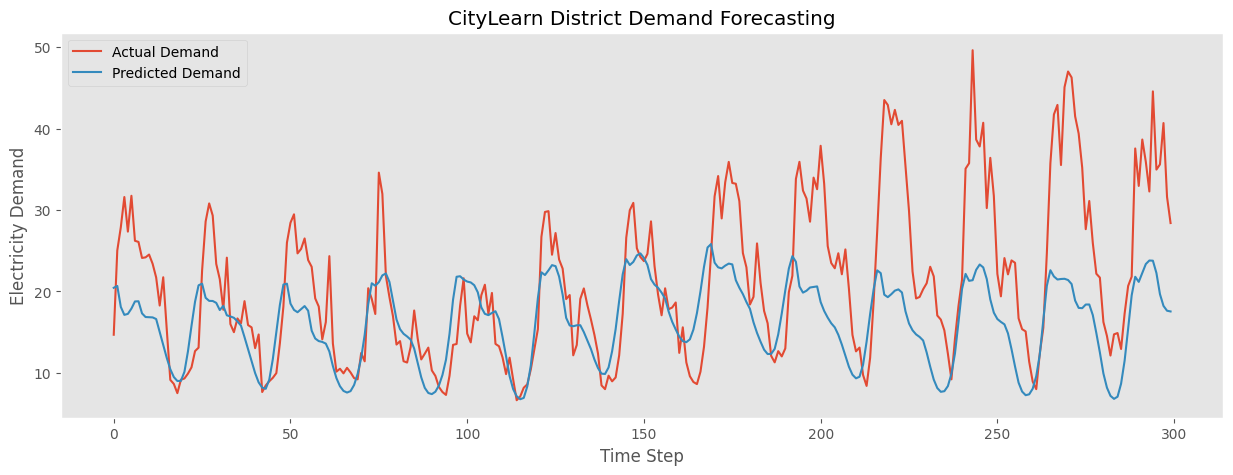

In [54]:
plt.figure(figsize=(15,5))
plt.plot(y_test_unscaled[:300], label='Actual Demand')
plt.plot(y_pred[:300], label='Predicted Demand')
plt.title('CityLearn District Demand Forecasting')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

## Final Conclusion
In this open-ended project, CityLearn data was converted into a forecasting dataset and modeled using an LSTM neural network. The notebook demonstrates the complete machine learning workflow: data collection, cleaning, exploration, feature engineering, scaling, sequence creation, model training, prediction, and evaluation.

## Submitted By
**Student Name:** DANIYAL BASHARAT  
**Registration Number:** 22JZELE0467  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus
